<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Unsupervised_Learning__Clustering_KMeans_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Unsupervised Learning - Clustering & K-Means**
**NIELIT Ropar | NIELIT 6 Months AIML | With IIT Ropar**

---

## **What You Will Learn Today**
1. What is Unsupervised Learning?
2. What is Clustering and where is it used?
3. K-Means Clustering - Intuition + Algorithm
4. Hands-on: K-Means from scratch and with Scikit-Learn
5. **Mini Project:** Customer Segmentation

---

**Previous Lesson:** https://colab.research.google.com/drive/1uocUh0pEgFOOGICUIZJglKvD8N5otluh?usp=sharing

## **1. What is Unsupervised Learning?**

In **supervised learning**, we train with labeled data (input → known output).  
In **unsupervised learning**, we have **no labels**. The algorithm finds hidden patterns by itself.

| Feature | Supervised | Unsupervised |
|---|---|---|
| Labels | Required | Not Required |
| Goal | Predict output | Discover structure |
| Examples | Classification, Regression | Clustering, Dimensionality Reduction |

---

## **2. What is Clustering?**

**Clustering** = Grouping similar data points together.

Think of it like sorting a box of mixed fruits — apples go together, bananas go together — **without anyone telling you the categories**.

### Real-World Use Cases
| Domain | Use Case |
|---|---|
| 🛒 E-Commerce | Customer segmentation (group buyers by behavior) |
| 🏥 Healthcare | Group patients by symptoms |
| 📰 News | Topic grouping of articles |
| 🔐 Cybersecurity | Anomaly / fraud detection |
| 🗺️ Maps | Geographic region clustering |
| 🧬 Biology | Gene expression grouping |

---

## **3. K-Means Clustering - Intuition**

**K-Means** divides data into **K clusters** by minimizing the distance between points and their cluster center (centroid).

### Algorithm Steps
```
1. Choose K (number of clusters)
2. Randomly place K centroids
3. Assign each point to the nearest centroid
4. Move each centroid to the mean of its assigned points
5. Repeat steps 3–4 until centroids stop moving
```

### 📐 Distance Formula (Euclidean)
$$d(A, B) = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

---

In [ ]:
# Install & Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


## **4. Visualizing a Clustering Problem**

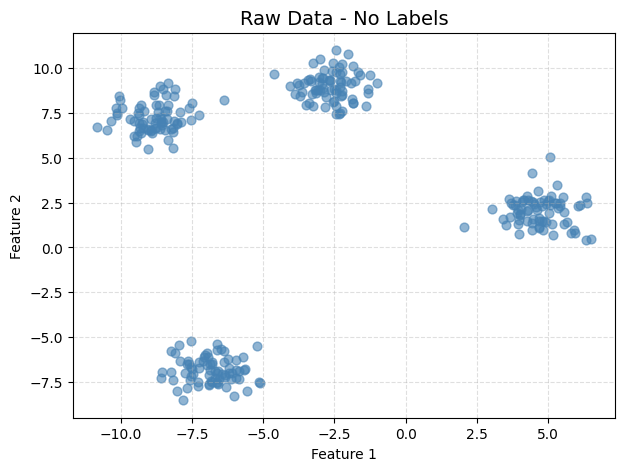

Data shape: (300, 2)  |  Total points: 300


In [ ]:
# Generate synthetic data with 4 natural clusters
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.8, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=40, color='steelblue', alpha=0.6)
plt.title('Raw Data - No Labels', fontsize=14)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print(f"Data shape: {X.shape}  |  Total points: {len(X)}")

## 5. **K-Means from Scratch (Step by Step)**

Converged at iteration 7


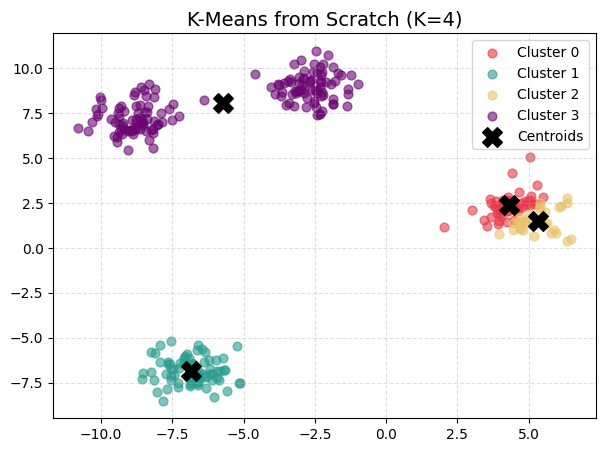

In [ ]:
def kmeans_scratch(X, k, max_iters=100, random_state=42):
    """
    K-Means implementation from scratch.
    Returns: centroids, labels
    """
    np.random.seed(random_state)

    # Step 1: Randomly pick K initial centroids
    idx = np.random.choice(len(X), k, replace=False)
    centroids = X[idx].copy()

    for iteration in range(max_iters):
        # Step 2: Assign each point to nearest centroid
        distances = np.array([[np.linalg.norm(x - c) for c in centroids] for x in X])
        labels = np.argmin(distances, axis=1)

        # Step 3: Recompute centroids
        new_centroids = np.array([X[labels == j].mean(axis=0) for j in range(k)])

        # Step 4: Check convergence
        if np.allclose(centroids, new_centroids):
            print(f"Converged at iteration {iteration + 1}")
            break
        centroids = new_centroids

    return centroids, labels

# Run our scratch implementation
centroids, labels = kmeans_scratch(X, k=4)

# Visualize result
colors = ['#E63946', '#2A9D8F', '#E9C46A', '#6A0572']
plt.figure(figsize=(7, 5))
for i in range(4):
    plt.scatter(X[labels == i, 0], X[labels == i, 1],
                s=40, color=colors[i], alpha=0.6, label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=200, marker='X', color='black', label='Centroids', zorder=5)
plt.title('K-Means from Scratch (K=4)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## 6. **K-Means with Scikit-Learn**

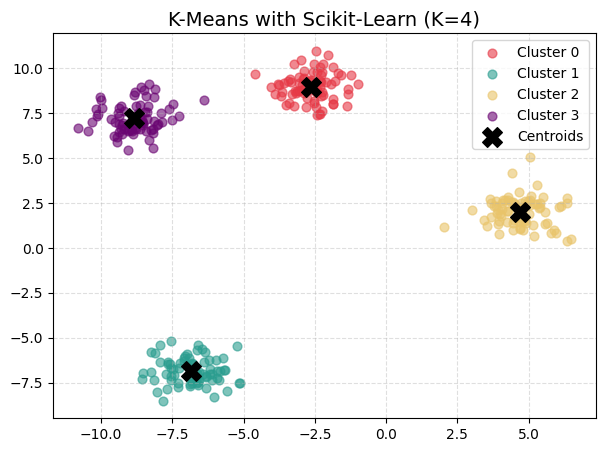

Inertia (WCSS): 362.47
Inertia = sum of squared distances of samples to their nearest centroid (lower = better)


In [ ]:
# Using sklearn's KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

labels_sk = kmeans.labels_
centroids_sk = kmeans.cluster_centers_

plt.figure(figsize=(7, 5))
for i in range(4):
    plt.scatter(X[labels_sk == i, 0], X[labels_sk == i, 1],
                s=40, color=colors[i], alpha=0.6, label=f'Cluster {i}')
plt.scatter(centroids_sk[:, 0], centroids_sk[:, 1],
            s=200, marker='X', color='black', label='Centroids', zorder=5)
plt.title('K-Means with Scikit-Learn (K=4)', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print(f"Inertia (WCSS): {kmeans.inertia_:.2f}")
print("Inertia = sum of squared distances of samples to their nearest centroid (lower = better)")

## 7. **How to Choose K?** - The Elbow Method

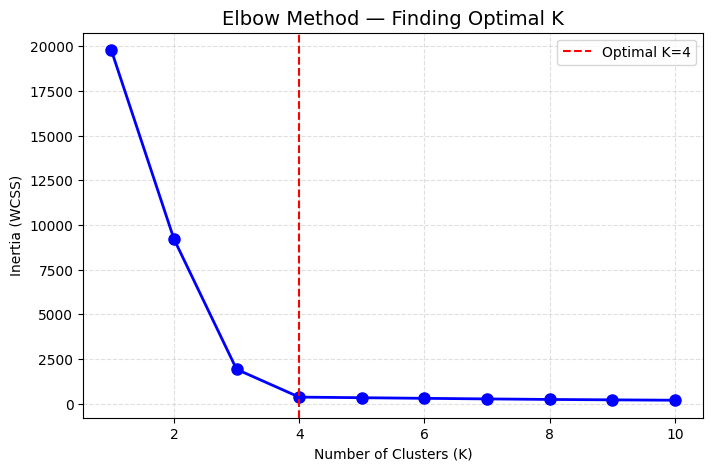

Look for the 'elbow' — where inertia stops dropping sharply.
That K is the sweet spot!


In [ ]:
# Elbow method: plot inertia for K = 1 to 10
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
plt.axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
plt.title('Elbow Method — Finding Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("Look for the 'elbow' — where inertia stops dropping sharply.")
print("That K is the sweet spot!")

## 8. ⚠️ **Limitations of K-Means**

| Limitation | Explanation |
|---|---|
| Must specify K | You need to choose the number of clusters manually |
| Sensitive to outliers | Outliers can pull centroids away |
| Assumes spherical clusters | Doesn't work well with non-circular shapes |
| Random initialization | Different runs may give different results (use `n_init`) |

---

## **Mini Project: Customer Segmentation**

In [ ]:
import pandas as pd

# Simulate a customer dataset
np.random.seed(42)
n = 200
data = {
    'Annual_Income_k': np.concatenate([
        np.random.normal(20, 5, 50),   # Low income
        np.random.normal(60, 8, 80),   # Mid income
        np.random.normal(100, 10, 70)  # High income
    ]),
    'Spending_Score': np.concatenate([
        np.random.normal(80, 8, 50),   # High spenders
        np.random.normal(50, 10, 80),  # Moderate spenders
        np.random.normal(20, 7, 70)    # Low spenders
    ])
}
df = pd.DataFrame(data)
df['Annual_Income_k'] = df['Annual_Income_k'].clip(5, 130)
df['Spending_Score'] = df['Spending_Score'].clip(1, 100)

print("Customer Dataset Preview:")
print(df.head(10))
print(f"\nShape: {df.shape}")

Customer Dataset Preview:
   Annual_Income_k  Spending_Score
0        22.483571       82.862299
1        19.308678       84.486276
2        23.238443       88.664410
3        27.615149       88.430416
4        18.829233       68.978645
5        18.829315       72.497400
6        27.896064       84.120282
7        23.837174       84.110288
8        17.652628       84.120381
9        22.712800      100.000000

Shape: (200, 2)


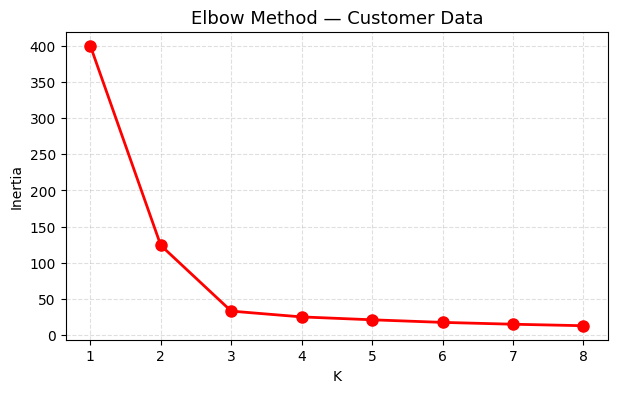

In [ ]:
# Scale features
scaler = StandardScaler()
X_cust = scaler.fit_transform(df)

# Find optimal K
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cust).inertia_
            for k in range(1, 9)]

plt.figure(figsize=(7, 4))
plt.plot(range(1, 9), inertias, 'ro-', linewidth=2, markersize=8)
plt.title('Elbow Method — Customer Data', fontsize=13)
plt.xlabel('K')
plt.ylabel('Inertia')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

Cluster Centroids (original scale):
  Cluster 0: Income=$60k, Spending Score=51
  Cluster 1: Income=$100k, Spending Score=20
  Cluster 2: Income=$19k, Spending Score=81


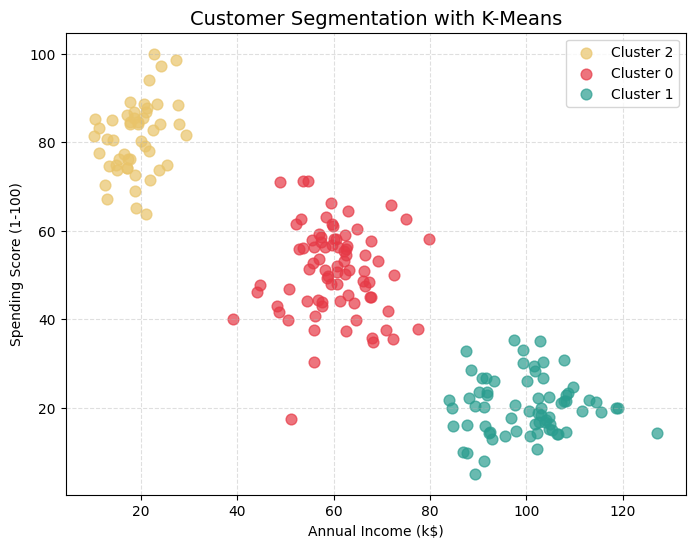


 Cluster Summary:
         Annual_Income_k  Spending_Score
Cluster                                 
0                  60.25           50.92
1                 100.09           20.22
2                  18.87           80.99


In [ ]:
# Apply K-Means with K=3
km_cust = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = km_cust.fit_predict(X_cust)

# Label segments meaningfully
segment_names = {0: 'Budget Shoppers', 1: 'Mid-Tier Customers', 2: 'Premium Customers'}

# Note: cluster IDs from K-Means are arbitrary — assign names based on centroid analysis
centroids_orig = scaler.inverse_transform(km_cust.cluster_centers_)
print("Cluster Centroids (original scale):")
for i, c in enumerate(centroids_orig):
    print(f"  Cluster {i}: Income=${c[0]:.0f}k, Spending Score={c[1]:.0f}")

seg_colors = {0: '#E63946', 1: '#2A9D8F', 2: '#E9C46A'}
plt.figure(figsize=(8, 6))
for cluster_id in df['Cluster'].unique():
    subset = df[df['Cluster'] == cluster_id]
    plt.scatter(subset['Annual_Income_k'], subset['Spending_Score'],
                color=seg_colors[cluster_id], s=60, alpha=0.7,
                label=f'Cluster {cluster_id}')
plt.title('Customer Segmentation with K-Means', fontsize=14)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print("\n Cluster Summary:")
print(df.groupby('Cluster')[['Annual_Income_k', 'Spending_Score']].mean().round(2))

# **Summary**

| Topic | Key Takeaway |
|---|---|
| Unsupervised Learning | No labels needed — find patterns automatically |
| Clustering | Group similar data points together |
| K-Means | Assign points to K centroids, iteratively improve |
| Elbow Method | Plot inertia vs K, pick the "elbow" |
| Customer Segmentation | Real-world clustering application |

---
**🔜 Tomorrow:** Hierarchical Clustering - no need to specify K upfront!


## **Exercises**
1. Change `n_clusters` to 2 and 5 in the customer segmentation. What changes?
2. Try `cluster_std=2.0` in `make_blobs`. How does higher spread affect K-Means?
3. Add a third feature `Age` to the customer dataset and re-cluster. Use a 3D plot if you like!


**References:**




*   https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
*   https://medium.com/@abhaysingh71711/k-means-clustering-a-deep-dive-into-unsupervised-learning-81213f56cfc9

*   https://towardsdatascience.com/unsupervised-learning-k-means-clustering-27416b95af27/

* https://www.kaggle.com/code/jrmrmh/k-means-clustering-ipynb

* https://github.com/zotroneneis/machine_learning_basics/blob/master/kmeans.ipynb

* https://www.kaggle.com/code/khotijahs1/k-means-clustering-of-iris-dataset

* https://github.com/mayursrt/k-means-on-iris-dataset/blob/main/Prediction%20using%20Unsupervised%20ML.ipynb




---



**Next:** Hierarchical_Clustering